# Практика 02. TF-IDF

## Задача: классификация твитов по тональности

У нас есть выборка из твитов.
Нам известна эмоциональная окраска каждого твита из выборки: положительная или отрицательная. Задача состоит в построении модели, которая по тексту твита предсказывает его эмоциональную окраску.

Классификацию по тональности используют в рекомендательных системах, чтобы понять, понравилось ли людям кафе, кино, etc.

Скачать выборку можно по ссылкам или же воспользовать уже скачанными файлами ([источник](http://study.mokoron.com/)): [положительные](https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv?dl=0), [отрицательные](https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv).

In [1]:
# если вы работете в GoogleCollab, где работает wget, то данные можно скачать данные так:
#%%capture
!wget https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv
!wget https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv

--2026-03-04 08:41:28--  https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv
Распознаётся www.dropbox.com (www.dropbox.com)… 162.125.66.18, 2620:100:6026:18::a27d:4612
Подключение к www.dropbox.com (www.dropbox.com)|162.125.66.18|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 302 Found
Адрес: https://www.dropbox.com/scl/fi/6mg7rw3wltux83q2o4ah4/positive.csv?rlkey=cvruhzofza9kkfxwzyp2vskfd [переход]
--2026-03-04 08:41:28--  https://www.dropbox.com/scl/fi/6mg7rw3wltux83q2o4ah4/positive.csv?rlkey=cvruhzofza9kkfxwzyp2vskfd
Повторное использование соединения с www.dropbox.com:443.
HTTP-запрос отправлен. Ожидание ответа… 302 Found
Адрес: https://uc3fadbc0507a864d2deb51bbb49.dl.dropboxusercontent.com/cd/0/inline/C8D7hjnKRdD4k7vrOpgSNkzT2dIB1rxJuNVlXq3Ky7-4t8FQV_HvVstG3hqCqAmJCJbgyMmnmDsQrJ5UxQSEumKM8svNVHWI1lDyATImEDhMDGPgnylCbRbm3isI9lJy8fA/file# [переход]
--2026-03-04 08:41:29--  https://uc3fadbc0507a864d2deb51bbb49.dl.dropboxusercontent.com/cd/0/inline/C8D7hjnKR

In [2]:
import pandas as pd # библиотека для удобной работы с датафреймами
import numpy as np # библиотека для удобной работы со списками и матрицами

# библиотека, где реализованы основные алгоритмы машинного обучения
from sklearn.metrics import * 
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline

Откроем файлы и создадим массив из текстов и правильных меток для твитов.
Сначала идут положительные твиты, потом отрицательные.

In [4]:
# загружаем положительные твиты
positive = pd.read_csv('positive.csv', sep=';', usecols=[3], names=['text'])
positive['label'] = ['positive'] * len(positive) # устанавливаем метки

# загружаем отрицательные твиты
negative = pd.read_csv('negative.csv', sep=';', usecols=[3], names=['text'])
negative['label'] = ['negative'] * len(negative) # устанавливаем метки

# соединяем вместе
df = pd.concat([positive, negative], ignore_index=True)

Посмотрим на полученные данные:

In [5]:
df.sample(5, random_state=40)

,text,label
15931,RT @Blawar_1337: Теперь у нас с @Wake_UA появи...,positive
59532,с днём рождения зайка*))) ухх погуляем мы сего...,positive
162096,RT @Shumkova0406199: @ann_safina Вов вов вов А...,negative
42002,"Надо выдернуть звуковую дорожку из ""Доктора Ка...",positive
223946,@_hassliebe_ может все таки на этой неделе вер...,negative


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 226834 entries, 0 to 226833
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    226834 non-null  str  
 1   label   226834 non-null  str  
dtypes: str(2)
memory usage: 3.5 MB


Разбиваем данные на обучающую и тестовую выборки с помощью функции ```train_test_split()``` из **sklearn**:


In [7]:
x_train, x_test, y_train, y_test = train_test_split(df.text, df.label)

## Baseline: классификация необработанных n-грамм

* Сначала попробуем получить преобразование предложений в численный вектор, с которым может работать стандартный алгоритм машинного обучения, например логистическая регрессия. 
* Для этого нам понадобится познакомиться с понятием n-gram - самых мелких элементов предложения, с которыми можно работать. 
* Подсчитав количество этих n-грам в предложениях, мы получим искомые численные представления.

Функция для работы с n-граммами реализована в библиотке **nltk** (Natural Language ToolKit), импортируем эту функцию: 

In [9]:
!pip install nltk

  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.2 MB/s  0:00:005.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.5/801.5 kB 7.5 MB/s  0:00:00
Using cached click-8.3.1-py3-none-any.whl (108 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]━━━━━━ 3/4 [nltk]]


In [10]:
from nltk import ngrams

Прежде чем получать n-граммы, нужно разделить предложение на отдельные слова.  Для этого используем метод ```split()```.

In [11]:
sentence = 'Кому нужен ломтик июльского неба?'.split()
sentence

['Кому', 'нужен', 'ломтик', 'июльского', 'неба?']

Чтобы получить n-грамму для такой последовательности, используем функцию ```ngrams()```. 

На вход подается два параметра:
* список с разделенным на отдельные слова предложением (у нас он хранится в переменной ```sentence```);
* параметр n, определяющий, какой тип n-грамм мы хотим получить.


Чтобы полученный объект отобразить, делаем из него ```list```. 

In [12]:
list(ngrams(sentence, 1)) # униграммы

[('Кому',), ('нужен',), ('ломтик',), ('июльского',), ('неба?',)]

Аналогично мы можем получить биграммы - для этого заменяем параметр **n** в функции **ngrams** с 1 на 2.

In [13]:
list(ngrams(sentence, 2)) # биграммы

[('Кому', 'нужен'),
 ('нужен', 'ломтик'),
 ('ломтик', 'июльского'),
 ('июльского', 'неба?')]

In [14]:
list(ngrams(sentence, 3)) # триграммы

[('Кому', 'нужен', 'ломтик'),
 ('нужен', 'ломтик', 'июльского'),
 ('ломтик', 'июльского', 'неба?')]

In [15]:
list(ngrams(sentence, 4))

[('Кому', 'нужен', 'ломтик', 'июльского'),
 ('нужен', 'ломтик', 'июльского', 'неба?')]

### Векторизаторы

Векторизатор преобразует слово или набор слов в числовой вектор, понятный алгоритму машинного обучения, который привык работать с числовыми табличными данными.

Ниже - пример преобразования слов в двумерных вектор, каждому слову соответствует точка на плоскости.

![Рисунок](img/download.png)


На начальном этапе нам будет достаточно тех инструментов, которые уже есть в знакомой нам библиотеке **sklearn**.

In [16]:
from sklearn.linear_model import LogisticRegression # можно заменить на любой другой классификатор
from sklearn.feature_extraction.text import CountVectorizer # модель "мешка слов"

Самый простой способ извлечь признаки из текстовых данных -- векторизаторы: `CountVectorizer` и `TfidfVectorizer`

Объект `CountVectorizer` делает следующее:
* строит для каждого документа (каждой пришедшей ему строки) вектор размерности `n`, где `n` -- количество слов или n-грам во всем корпусе
* заполняет каждый i-тый элемент количеством вхождений слова в данный документ

![Рисунок](img/download2.png)

На рисунке пример векторизации для униграмм, но можно использовать любые n-граммы. Для этого у объекта ```CountVectorizer()``` есть параметр **ngram_range**, который отвечает за то, какие n-граммы мы используем в качестве признаов:<br/>
ngram_range=(1, 1) -- униграммы<br/>
ngram_range=(3, 3) -- триграммы<br/>
ngram_range=(1, 3) -- униграммы, биграммы и триграммы.

Инициализируем ```CountVectorizer()```, указав в качестве признаков униграммы:

In [17]:
vectorizer = CountVectorizer(ngram_range=(1, 1))

После инициализации _vectorizer_ можно обучить на наших данных. 

Для обучения используем обучающую выборку ```x_train```, но в отличие от классификатора мы используем метод ```fit_transform()```: сначала обучаем наш векторизатор, а потом сразу применяем его к набору данных. Это похоже на то, как работает label encoder и one-hot-encoder.


In [18]:
vectorized_x_train = vectorizer.fit_transform(x_train)

Так как результат не зависит от порядка слов в текстах, то говорят, что такая модель представления текстов в виде векторов получается из *гипотезы представления текста как мешка слов*

В vectorizer.vocabulary_ лежит словарь, отображение слов в их индексы:

In [19]:
list(vectorizer.vocabulary_.items())[:10]

[('evgenbulankin', 30106),
 ('тогда', 222101),
 ('на', 161480),
 ('улицу', 227055),
 ('вышел', 118121),
 ('там', 219750),
 ('народ', 163833),
 ('ищу', 141807),
 ('столько', 216763),
 ('было', 109146)]

В нашей выборке 170125 текстов (твитов), в них встречается 243760 разных слов.

In [20]:
vectorized_x_train.shape

(170125, 243718)

In [26]:
# Создаем DataFrame для первых 5 строк
# Берем первые 5 строк и преобразуем в плотную матрицу
dense_subset = vectorized_x_train[:5].toarray()

feature_names = vectorizer.get_feature_names_out()
# Создаем DataFrame с именами признаков
df_view = pd.DataFrame(dense_subset, columns=feature_names)

# Транспонируем и показываем только ненулевые значения для компактности
df_nonzero = df_view.loc[:, (df_view != 0).any(axis=0)]
print("Первые 5 документов (только слова с ненулевыми значениями):")
print(df_nonzero)

Первые 5 документов (только слова с ненулевыми значениями):
   co  dbp1dmmb7w  dksribgmpz  evgenbulankin  http  vasmesha  было  вышел  \
0   0           0           0              1     0         0     1      1   
1   1           1           0              0     1         1     0      0   
2   0           0           0              0     0         0     0      0   
3   1           0           1              0     1         0     0      0   
4   0           0           0              0     0         0     0      0   

   гнобили  доброй  ...  там  тогда  трогни  улицу  улыбаются  унижали  хочу  \
0        0       0  ...    1      1       0      1          0        0     0   
1        0       0  ...    0      0       0      0          0        0     0   
2        1       0  ...    0      0       0      0          1        1     0   
3        0       0  ...    0      0       1      0          0        0     0   
4        0       1  ...    0      0       0      0          0        0     1 

Так как теперь у нас есть **численное представление** и набор входных признаков, то мы можем обучить модель логистической регрессии (или любую другую)

In [27]:
%%time
clf = LogisticRegression(random_state=88, max_iter=1000) # фиксируем random_state для воспроизводимости результатов
clf.fit(vectorized_x_train, y_train)

CPU times: user 1min 10s, sys: 68.7 ms, total: 1min 10s
Wall time: 29.6 s


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",88
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

С тестовыми данными нужно проделать то же самое, что и с данными для обучения: сделать из текстов вектора, которые можно передавать в классификатор для прогноза класса объекта. 

У нас уже есть обученный векторизатор ```vectorizer```, поэтому используем метод ```transform()``` (просто применить его), а не ```fit_transform``` (обучить и применить).

In [28]:
vectorized_x_test = vectorizer.transform(x_test)

Как раньше, для получения прогноза у обученного классификатора используем метод ```predict()```.

С помощью функции ```classification_report()```, которая считает сразу несколько метрик качества классификации, посмотрим на то, насколько хорошо мы предсказываем положительную или отрицательную тональность твита .

In [29]:
pred = clf.predict(vectorized_x_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.77      0.77      0.77     28197
    positive       0.77      0.77      0.77     28512

    accuracy                           0.77     56709
   macro avg       0.77      0.77      0.77     56709
weighted avg       0.77      0.77      0.77     56709



## Использование триграмм

Попробуем сделать то же самое, используя в качестве признаков триграммы:

In [30]:
# инициализируем векторайзер 
trigram_vectorizer = CountVectorizer(ngram_range=(1, 3))

# обучаем его и сразу применяем к x_train
trigram_vectorized_x_train = trigram_vectorizer.fit_transform(x_train)

# инициализируем и обучаем классификатор
clf = LogisticRegression(random_state=88, max_iter=1000)
clf.fit(trigram_vectorized_x_train, y_train)

# применяем обученный векторизатор к тестовым данным
trigram_vectorized_x_test = trigram_vectorizer.transform(x_test)

# получаем предсказания и выводим информацию о качестве
pred = clf.predict(trigram_vectorized_x_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.78      0.78      0.78     28197
    positive       0.79      0.79      0.79     28512

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.78     56709
weighted avg       0.78      0.78      0.78     56709



## TF-IDF векторизация

`TfidfVectorizer` делает то же, что и `CountVectorizer`, но в качестве значений выдает **tf-idf** каждого слова.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

Действуем аналогично, как с ```CountVectorizer()```:

In [32]:
%%time
# инициализируем векторизатор, в качестве переменных используем униграммы
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 3))

# обучаем его и сразу применяем к x_train
tfidf_vectorized_x_train = tfidf_vectorizer.fit_transform(x_train)

# инициализируем и обучаем классификатор
clf = LogisticRegression(random_state=88, max_iter=1000)
clf.fit(tfidf_vectorized_x_train, y_train)

# применяем обученный векторизатор к тестовым данным
tfidf_vectorized_x_test = tfidf_vectorizer.transform(x_test)

# получаем предсказания и выводим информацию о качестве
pred = clf.predict(tfidf_vectorized_x_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.76      0.76      0.76     28197
    positive       0.76      0.76      0.76     28512

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709

CPU times: user 1min 38s, sys: 937 ms, total: 1min 39s
Wall time: 36.5 s


Результат не улучшился, поэтому вернемся к `CountVectorizer()`.

## Токенизация

Токенизировать - значит, поделить текст на части: слова, ключевые слова, фразы, символы и т.д., иными словами **токены**.

Самый простой способ токенизировать текст - разделить с помощью функции `split()`. Но `split` упускает очень много всего, например, не отделяет пунктуацию от слов. Кроме этого, есть еще много менее тривиальных проблем, поэтому лучше использовать готовые токенизаторы.

In [33]:
import nltk # уже знакомая нам библиотека nltk
from nltk.tokenize import word_tokenize # готовый токенизатор библиотеки nltk

Чтобы использовать токенизатор ```word_tokenize```, нужно сначала скачать данные для nltk о пунктуации и стоп-словах. Это просто требование nltk, поэтому просто скачаем требумую информацию:  

In [34]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/sasha/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /home/sasha/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [36]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/sasha/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Применим токенизацию:

In [37]:
example = 'Но не каждый хочет что-то исправлять:('
word_tokenize(example)

['Но', 'не', 'каждый', 'хочет', 'что-то', 'исправлять', ':', '(']

Если использовать просто ```split()```, то знаки пунктуации :( не отделяются от слова "исправлять":

In [38]:
example.split()

['Но', 'не', 'каждый', 'хочет', 'что-то', 'исправлять:(']

В nltk вообще есть довольно много токенизаторов:

In [39]:
from nltk import tokenize
dir(tokenize)[:30]

['BlanklineTokenizer',
 'LegalitySyllableTokenizer',
 'LineTokenizer',
 'MWETokenizer',
 'NLTKWordTokenizer',
 'PunktSentenceTokenizer',
 'PunktTokenizer',
 'RegexpTokenizer',
 'ReppTokenizer',
 'SExprTokenizer',
 'SpaceTokenizer',
 'StanfordSegmenter',
 'SyllableTokenizer',
 'TabTokenizer',
 'TextTilingTokenizer',
 'ToktokTokenizer',
 'TreebankWordDetokenizer',
 'TreebankWordTokenizer',
 'TweetTokenizer',
 'WhitespaceTokenizer',
 'WordPunctTokenizer',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']

Они умеют выдавать индексы в строке для начала и конца каждого слова-токена:

In [40]:
wh_tok = tokenize.WhitespaceTokenizer()
list(wh_tok.span_tokenize(example))

[(0, 2), (3, 5), (6, 12), (13, 18), (19, 25), (26, 38)]

Некторые токенизаторы ведут себя специфично:

In [41]:
tokenize.TreebankWordTokenizer().tokenize("don't stop me")

['do', "n't", 'stop', 'me']

А некоторые -- вообще не для текста на естественном языке:

In [42]:
tokenize.SExprTokenizer().tokenize("(a (b c)) d e (f)")

['(a (b c))', 'd', 'e', '(f)']

**Подходящий токенизатор подбирается исходя из требований задачи!**

## Стоп-слова и пунктуация

**Стоп-слова** - это слова, которые часто встречаются практически в любом тексте и ничего интересного не говорят о конретном документе. Для модели это просто шум. А шум нужно убирать. По аналогичной причине убирают и пунктуацию.

In [43]:
# импортируем стоп-слова из библиотеки nltk
from nltk.corpus import stopwords

# посмотрим на стоп-слова для русского языка
print(stopwords.words('russian'))

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впр

*Знаки* пунктуации лучше импортировать из модуля **String**. В нем хранятся различные наборы констант для работы со строками (пунктуация, алфавит и др.). 

In [44]:
from string import punctuation
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

Объединим стоп-слова и знаки пунктуации вместе и запишем в переменную ```noise```:

In [45]:
noise = stopwords.words('russian') + list(punctuation)
print(noise)

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впр

Теперь нужно обучить нашу модель с учетом новых знаний про токенизацию и стоп-слова. 

Для этого мы можем собрать новый векторизатор, передав ему на вход:
* какие n-граммы нам нужны, параметр **ngram_range**;
* какой токенизатор мы используем, параметр **tokenizer**;
* какие у нас стоп-слова, параметр **stop_words**.

*Напоминание:* мы используем готовый токенизатор ```word_tokenize```, а стоп-слова хранятся в переменной ```noise```

In [46]:
# инициализируем умный векторайзер 
smart_vectorizer = CountVectorizer(ngram_range=(1, 3), 
                                   tokenizer=word_tokenize, 
                                   stop_words=noise)

In [47]:
%%time
# обучаем его и сразу применяем к x_train
smart_vectorized_x_train = smart_vectorizer.fit_transform(x_train)

# инициализируем и обучаем классификатор
clf = LogisticRegression(random_state=88, max_iter=1000)
clf.fit(smart_vectorized_x_train, y_train)

# применяем обученный векторайзер к тестовым данным
smart_vectorized_x_test = smart_vectorizer.transform(x_test)

# получаем предсказания и выводим информацию о качестве
pred = clf.predict(smart_vectorized_x_test)
print(classification_report(y_test, pred))

/home/sasha/miniconda3/envs/nlp_course/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/home/sasha/miniconda3/envs/nlp_course/lib/python3.14/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['``'] not in stop_words.
  warnings.warn(


              precision    recall  f1-score   support

    negative       0.77      0.82      0.79     28197
    positive       0.81      0.76      0.78     28512

    accuracy                           0.79     56709
   macro avg       0.79      0.79      0.79     56709
weighted avg       0.79      0.79      0.79     56709

CPU times: user 2min 52s, sys: 566 ms, total: 2min 52s
Wall time: 1min 8s


Результат стал немного лучше: accuracy выше, а также заметно подрос recall у негативного класса.

## Практическое задание

1.	Выполните исследование величины n в n-граммах на результаты (как меняется результаты обучения одной и той же модели, при изменении n, значение можно варьировать от 1 до 5).
2.	Выполните обучение другой модели машинного обучения. Показать изменится ли от этого результат по сравнению с логистической регрессией.
3.	Исследуйте влияние стоп слов на результаты классификации, если все сделать правильно, то можно получить абсолютную точность, т.е. значения всех метрик будут равны 1.

# Задание 1

In [66]:
noise += ['``']

In [67]:
def fit_and_check(smart_vectorizer):
    smart_vectorized_x_train = smart_vectorizer.fit_transform(x_train)
    
    clf = LogisticRegression(random_state=88, max_iter=1000)
    clf.fit(smart_vectorized_x_train, y_train)
    
    smart_vectorized_x_test = smart_vectorizer.transform(x_test)
    
    pred = clf.predict(smart_vectorized_x_test)
    print(classification_report(y_test, pred))

In [68]:
for i in range (1, 6):
    smart_vectorizer = CountVectorizer(ngram_range=(i, i), 
                                   tokenizer=word_tokenize, 
                                   stop_words=noise,
                                   token_pattern=None)
    fit_and_check(smart_vectorizer)

              precision    recall  f1-score   support

    negative       0.77      0.80      0.79     28197
    positive       0.80      0.76      0.78     28512

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.78     56709
weighted avg       0.78      0.78      0.78     56709

              precision    recall  f1-score   support

    negative       0.63      0.82      0.71     28197
    positive       0.75      0.52      0.61     28512

    accuracy                           0.67     56709
   macro avg       0.69      0.67      0.66     56709
weighted avg       0.69      0.67      0.66     56709

              precision    recall  f1-score   support

    negative       0.54      0.97      0.69     28197
    positive       0.87      0.17      0.29     28512

    accuracy                           0.57     56709
   macro avg       0.70      0.57      0.49     56709
weighted avg       0.70      0.57      0.49     56709

              preci

In [56]:
def train_and_evaluate_ngram(n, x_train, y_train, x_test, y_test, stop_words):
    vectorizer = CountVectorizer(
        ngram_range=(1, n),
        tokenizer=word_tokenize,
        stop_words=stop_words,
        token_pattern=None,
    )
    
    X_train_vec = vectorizer.fit_transform(x_train)
    X_test_vec = vectorizer.transform(x_test)
    
    model = LogisticRegression(
        random_state=88,
        max_iter=1000
    )
    
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    return {
        "n-gram": f"1–{n}",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted"),
        "Features": X_train_vec.shape[1]
    }

In [57]:
results = []

for n in range(1, 6):
    metrics = train_and_evaluate_ngram(
        n,
        x_train,
        y_train,
        x_test,
        y_test,
        noise
    )
    results.append(metrics)

In [61]:
df_results = pd.DataFrame(results)

df_results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}"
}).background_gradient(cmap="Blues")

,n-gram,Accuracy,Precision,Recall,F1-score,Features
0,1–1,0.7835,0.7840,0.7835,0.7834,259494
1,1–2,0.7897,0.7906,0.7897,0.7896,1213313
2,1–3,0.7883,0.7895,0.7883,0.7882,2195685
3,1–4,0.7872,0.7890,0.7872,0.7870,3033899
4,1–5,0.7862,0.7882,0.7862,0.7859,3718031


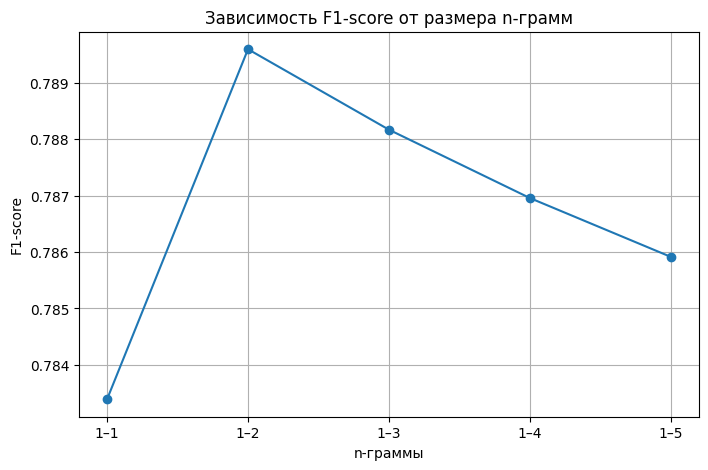

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_results["n-gram"], df_results["F1-score"], marker="o")
plt.title("Зависимость F1-score от размера n-грамм")
plt.xlabel("n-граммы")
plt.ylabel("F1-score")
plt.grid(True)
plt.show()

### Вывод по исследованию n-грамм

При использовании только n-грамм фиксированной длины (n,n) качество модели
резко снижается при увеличении n. Это связано с ростом размерности
признакового пространства и высокой разреженностью матрицы признаков.

Наилучшие результаты показала модель с ngram_range=(1,2),
что объясняется балансом между учётом контекста (биграммы)
и сохранением частотной устойчивости признаков (униграммы).

При дальнейшем увеличении n качество не улучшается,
а количество признаков растёт экспоненциально.

# Задания 2 и 3

In [69]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

def fit_and_report(model, vectorizer):
    X_train_vec = vectorizer.fit_transform(x_train)
    X_test_vec = vectorizer.transform(x_test)

    model.fit(X_train_vec, y_train)
    pred = model.predict(X_test_vec)

    print(type(model).__name__)
    print(classification_report(y_test, pred))
    print("="*50)

In [ ]:
vectorizer = CountVectorizer(
    ngram_range=(1,2),
    tokenizer=word_tokenize,
    stop_words=noise,
    token_pattern=None,
)

# Logistic Regression
fit_and_report(LogisticRegression(max_iter=1000), vectorizer)

# Naive Bayes
fit_and_report(MultinomialNB(), vectorizer)

# SVM
fit_and_report(LinearSVC(), vectorizer)

LogisticRegression
              precision    recall  f1-score   support

    negative       0.77      0.82      0.79     28197
    positive       0.81      0.76      0.79     28512

    accuracy                           0.79     56709
   macro avg       0.79      0.79      0.79     56709
weighted avg       0.79      0.79      0.79     56709

MultinomialNB
              precision    recall  f1-score   support

    negative       0.78      0.78      0.78     28197
    positive       0.78      0.79      0.79     28512

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.78     56709
weighted avg       0.78      0.78      0.78     56709

